# Import Libraries

The required libraries for data manipulation and analysis were imported.

In [1]:
import pandas as pd 

# Load Dataset

The retail sales dataset was loaded into a pandas DataFrame for analysis.

In [2]:
df = pd.read_csv("../data/retail_sales.csv")

In [3]:
df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


# Initial Data Exploration

The dataset was inspected to understand its structure, dimensions, data types, and summary statistics before cleaning.

In [4]:
df.shape

(51290, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment_method       51290 non-null 

In [6]:
df.describe()

,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
count,51289.000000,51290.000000,51289.000000,51288.000000,51289.000000,51290.000000,51289.000000
mean,5.255035,58155.758764,152.340872,2.502983,0.303821,70.407226,7.041557
std,2.959948,26032.215826,66.495419,1.511859,0.131027,48.729488,4.871745
min,1.000000,10000.000000,33.000000,1.000000,0.100000,0.500000,0.100000
25%,3.000000,35831.250000,85.000000,1.000000,0.200000,24.900000,2.500000
50%,5.000000,61018.000000,133.000000,2.000000,0.300000,59.900000,6.000000
75%,8.000000,80736.250000,218.000000,4.000000,0.400000,118.400000,11.800000
max,10.500000,99999.000000,250.000000,5.000000,0.500000,167.500000,16.800000


# Missing Values Analysis

The dataset was checked for missing values to identify potential data quality issues.

In [7]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
27,2018-05-02,11:45:38,NaN,26058,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,55.8,5.6,High,credit_card
95,2018-04-22,11:32:22,5.0,52267,Male,Web,Member,Auto & Accessories,Bike Tyres,72.0,NaN,0.1,36.0,3.6,Critical,credit_card
211,2018-08-05,17:27:54,6.0,47137,Male,Web,Member,Auto & Accessories,Tyre,250.0,5.0,NaN,132.5,13.3,Medium,credit_card
321,2018-06-05,11:04:11,3.0,41850,Male,Web,Member,Auto & Accessories,Car Mat,54.0,NaN,0.2,54.0,5.4,Critical,credit_card
535,2018-04-16,16:20:02,3.0,13777,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.2,150.0,NaN,Critical,credit_card
625,2018-10-15,20:16:34,2.0,26367,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.3,140.0,14.0,NaN,debit_card
791,2018-07-03,23:40:16,4.0,36902,Female,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231.0,1.0,0.1,148.7,14.9,NaN,money_order
793,2018-05-16,21:30:59,6.0,16381,Male,Web,Member,Auto & Accessories,Car Speakers,NaN,1.0,0.1,124.7,12.5,Critical,credit_card


In [9]:
df["Aging"].value_counts().sort_index()

1.0     7467
2.0     4815
3.0     5017
4.0     4875
5.0     4939
6.0     4891
7.0     4900
8.0     4820
9.0     4674
10.0    4890
10.5       1
Name: Aging, dtype: int64

# Data Cleaning

Rows containing missing values were removed since they represented a very small proportion of the dataset (8 out of 51,290 records, approximately 0.016%). Removing them has no significant impact on the analysis.

In [10]:
df = df.dropna()

In [12]:
df.shape

(51282, 16)

In [13]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  0
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Shipping_Cost          0
Order_Priority         0
Payment_method         0
dtype: int64

# Data Type Conversion

The `Order_Date` column was converted from object to datetime format to enable time-series analysis and date-based calculations.

In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51282 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_Date           51282 non-null  datetime64[ns]
 1   Time                 51282 non-null  object        
 2   Aging                51282 non-null  float64       
 3   Customer_Id          51282 non-null  int64         
 4   Gender               51282 non-null  object        
 5   Device_Type          51282 non-null  object        
 6   Customer_Login_type  51282 non-null  object        
 7   Product_Category     51282 non-null  object        
 8   Product              51282 non-null  object        
 9   Sales                51282 non-null  float64       
 10  Quantity             51282 non-null  float64       
 11  Discount             51282 non-null  float64       
 12  Profit               51282 non-null  float64       
 13  Shipping_Cost        51282 non-

## Customer and Product Overview

The following analysis summarizes the distribution of customer demographics, shopping channels, payment methods, and product categories.

In [16]:
df["Gender"].value_counts()

Male      28132
Female    23150
Name: Gender, dtype: int64

In [17]:
df["Device_Type"].value_counts()

Web       47624
Mobile     3658
Name: Device_Type, dtype: int64

In [18]:
df["Payment_method"].value_counts()

credit_card    38131
money_order     9628
e_wallet        2789
debit_card       733
not_defined        1
Name: Payment_method, dtype: int64

In [19]:
df["Product_Category"].value_counts()

Fashion               25646
Home & Furniture      15438
Auto & Accessories     7497
Electronic             2701
Name: Product_Category, dtype: int64

## Business Metrics

Key business indicators were calculated to provide an overview of sales performance.

In [20]:
df["Sales"].sum()

7812164.0

In [21]:
df["Profit"].sum()


3610344.9000000004

In [22]:
df["Quantity"].sum()

128357.0

# Exploratory Data Analysis

The objective of this section is to explore customer behavior, product performance, and sales trends through descriptive statistics and visualizations.

# Data Visualization

Visualizations were created to better understand customer behavior and business performance.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
sns.set_theme(style="whitegrid")


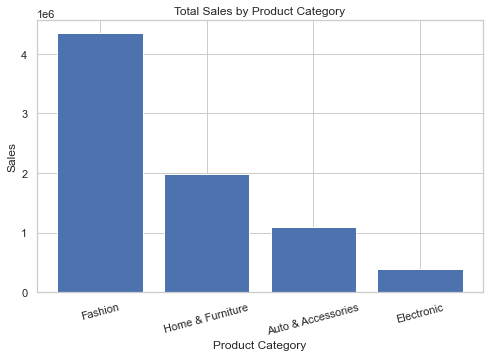

In [28]:
category_sales = (
    df.groupby("Product_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")

plt.xticks(rotation=15)

plt.show()

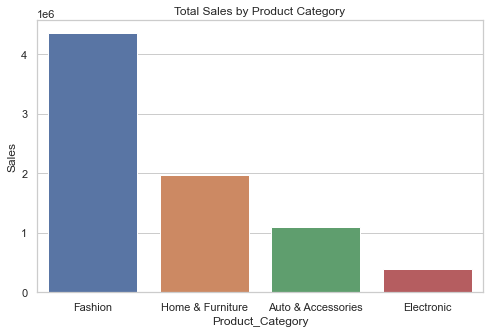

In [ ]:
category_sales = (
    df.groupby("Product_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Product_Category",
    y="Sales"
)

plt.title("Total Sales by Product Category")

plt.show()

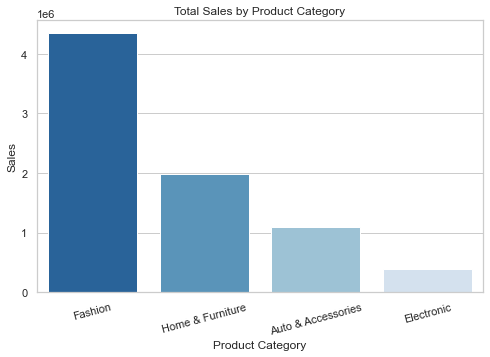

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Product_Category",
    y="Sales",
    palette="Blues_r"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.xticks(rotation=15)

plt.show()


### Insight

Fashion generated the highest total sales, followed by Home & Furniture.
Electronics contributed the lowest sales volume among all product categories.

## Monthly Sales Trend

This analysis shows how total sales evolved over time by grouping orders by month.

In [ ]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Order_Date"] = monthly_sales["Order_Date"].dt.to_timestamp()

monthly_sales.dtypes

monthly_sales 


Order_Date    datetime64[ns]
Sales                float64
dtype: object

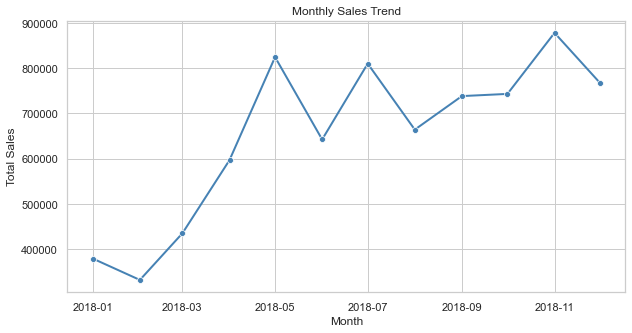

In [41]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_sales,
    x="Order_Date",
    y="Sales",
    marker="o",
    linewidth=2,
    color="steelblue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Insight

Sales showed an overall upward trend throughout the year, with noticeable peaks in May, July, and November. February had the lowest sales, while November recorded the highest monthly sales.

# Profit Analysis

This section analyzes profitability across product categories to identify which products generate the highest profit.

In [45]:
category_profit = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .reset_index()
)

category_profit

,Product_Category,Profit
0,Auto & Accessories,483471.5
1,Electronic,174190.6
2,Fashion,2072623.9
3,Home & Furniture,880058.9


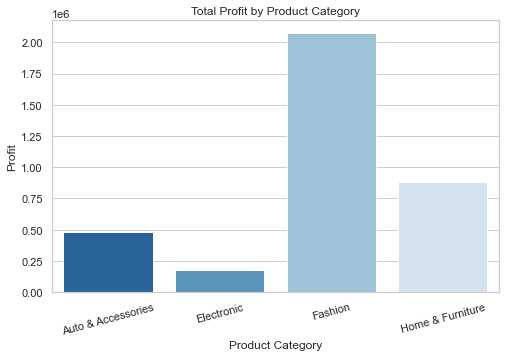

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_profit,
    x="Product_Category",
    y="Profit",
    palette="Blues_r"
)

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.xticks(rotation=15)

plt.show()

### Insight

Fashion generated the highest total profit by a significant margin, outperforming all other product categories. Home & Furniture ranked second, while Electronics produced the lowest overall profit despite contributing to total sales. This suggests that not all categories contribute equally to the company's profitability.

## Profit Margin Analysis

This analysis compares the profit margin across product categories to identify which categories are the most profitable relative to their sales.

In [47]:
category_margin = (
    df.groupby("Product_Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

category_margin

,Product_Category,Sales,Profit
0,Auto & Accessories,1095681.0,483471.5
1,Electronic,394738.0,174190.6
2,Fashion,4345914.0,2072623.9
3,Home & Furniture,1975831.0,880058.9


In [48]:
category_margin["Profit_Margin"] = (
    category_margin["Profit"] /
    category_margin["Sales"] * 100
)

category_margin

,Product_Category,Sales,Profit,Profit_Margin
0,Auto & Accessories,1095681.0,483471.5,44.125206
1,Electronic,394738.0,174190.6,44.128156
2,Fashion,4345914.0,2072623.9,47.691323
3,Home & Furniture,1975831.0,880058.9,44.541203


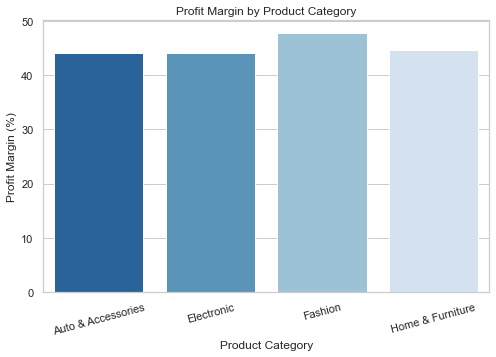

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_margin,
    x="Product_Category",
    y="Profit_Margin",
    palette="Blues_r"
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=15)

plt.show()

### Insight
Fashion was the strongest performing category across all profitability metrics. It generated the highest sales, the highest total profit, and also achieved the highest profit margin (47.7%), indicating both strong demand and high operational efficiency.

## Sales vs Profit Relationship

This scatter plot explores the relationship between sales and profit for individual orders.

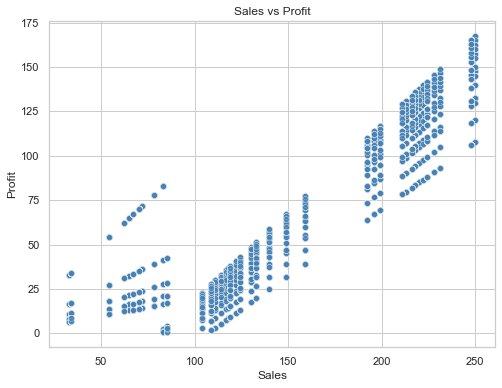

In [51]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.7,
    color="steelblue"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

### Insight
Sales and profit show a strong positive relationship. Orders with higher sales generally generate higher profits, indicating that profitability scales consistently with revenue. No major clusters of highly unprofitable orders were observed.

## Correlation Analysis
To better understand the relationships between the main numerical variables, a correlation matrix is calculated and visualized using a heatmap. This helps identify which variables move together and whether any strong positive or negative correlations exist.

In [53]:
#Generamos la Matriz de Correlacion

corr = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

corr

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.916762,0.015281,0.072594
Profit,0.916762,1.000000,-0.122108,-0.003123
Quantity,0.015281,-0.122108,1.000000,0.023087
Discount,0.072594,-0.003123,0.023087,1.000000


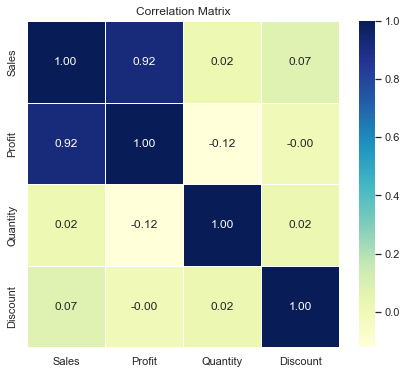

In [59]:
plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Matrix")

plt.show()

## Insight
Sales and Profit show a very strong positive correlation (0.92), suggesting that higher revenue is consistently associated with higher profitability. Quantity and Discount exhibit minimal correlation with the remaining numerical variables, indicating limited influence within this dataset.

# Top Products by Sales
This analysis identifies the products that generated the highest total sales, helping understand which items contribute most to the company's revenue.

In [61]:
top_products = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products

,Product,Sales
0,T - Shirts,578336.0
1,Titak watch,531468.0
2,Running Shoes,522144.0
3,Jeans,508376.0
4,Formal Shoes,496503.0
5,Shirts,457072.0
6,Fossil Watch,370788.0
7,Towels,351348.0
8,Sofa Covers,332424.0
9,Bed Sheets,325151.0


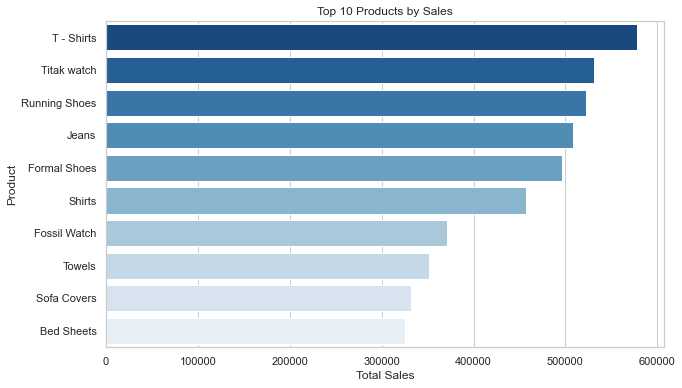

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products,
    x="Sales",
    y="Product",
    palette="Blues_r"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

### Insight
T-Shirts generated the highest total sales, followed closely by Titak Watch and Running Shoes. The top 10 products account for a substantial portion of total revenue, suggesting that focusing inventory, marketing, and promotions on these best-selling items could maximize business performance.

## Sales by Device Type

This analysis compares total sales generated through different device types.

In [65]:
device_sales = (
    df.groupby("Device_Type")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

device_sales

,Device_Type,Sales
0,Web,7248824.0
1,Mobile,563340.0


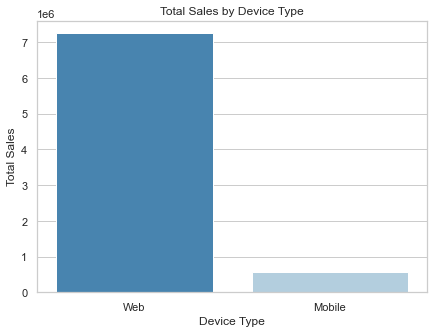

In [66]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=device_sales,
    x="Device_Type",
    y="Sales",
    palette="Blues_r"
)

plt.title("Total Sales by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Total Sales")

plt.show()

### Insight:

Web generated significantly higher sales than Mobile devices, indicating that customers primarily completed purchases through the website. This suggests that optimizing the web shopping experience should remain a priority while exploring opportunities to increase mobile adoption.

# Sales by Payment Method

This analysis compares total sales across different payment methods to understand customer payment preferences.

In [67]:
payment_sales = (
    df.groupby("Payment_method")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

payment_sales

,Payment_method,Sales
0,credit_card,5818613.0
1,money_order,1461038.0
2,e_wallet,422750.0
3,debit_card,109729.0
4,not_defined,34.0


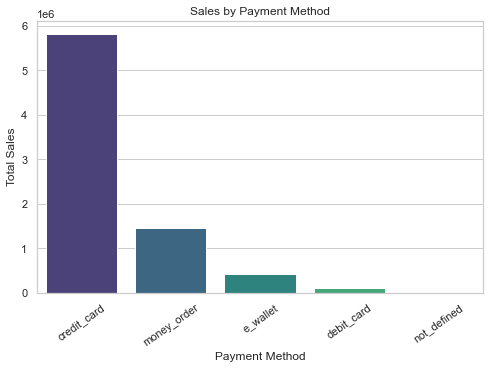

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_sales,
    x="Payment_method",
    y="Sales",
    palette="viridis"
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

plt.xticks(rotation=35)

plt.show()

### Insight

Credit cards dominate customer transactions, generating the vast majority of total sales. Money orders rank as the second most used payment method, while e-wallets and debit cards contribute a much smaller share. This distribution suggests that maintaining a seamless credit card payment experience is critical for maximizing revenue.

# Orders by Priority

This analysis shows the distribution of orders according to their assigned priority level.

In [70]:
priority_orders = (
    df["Order_Priority"]
      .value_counts()
      .reset_index()
)

priority_orders.columns = ["Priority", "Orders"]

priority_orders

,Priority,Orders
0,Medium,29432
1,High,15498
2,Critical,3928
3,Low,2424


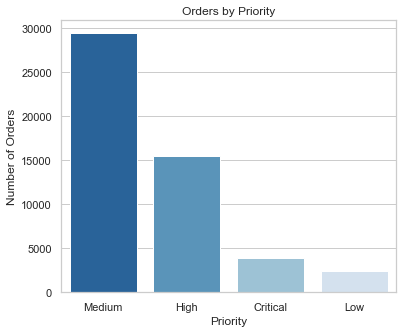

In [71]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=priority_orders,
    x="Priority",
    y="Orders",
    palette="Blues_r"
)

plt.title("Orders by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Orders")

plt.show()

### Insight 
Most orders are assigned Medium priority, followed by High priority orders. Critical and Low priority orders represent only a small fraction of the total workload, indicating that the majority of business operations focus on standard-priority processing.

# Customer Login Type

This analysis examines how customers access the platform, identifying the most common login methods.

In [72]:
login_type = (
    df["Customer_Login_type"]
      .value_counts()
      .reset_index()
)

login_type.columns = ["Login Type","Customers"]

login_type

,Login Type,Customers
0,Member,49089
1,Guest,1993
2,First SignUp,173
3,New,27


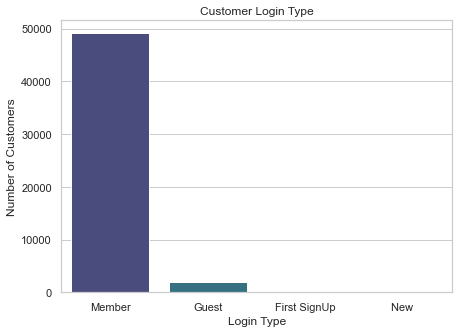

In [73]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=login_type,
    x="Login Type",
    y="Customers",
    palette="viridis"
)

plt.title("Customer Login Type")
plt.xlabel("Login Type")
plt.ylabel("Number of Customers")

plt.show()

## Insight

Most customers are registered members, while guest users represent only a small portion of the customer base. Very few purchases come from first-time sign-ups or newly created accounts, suggesting that repeat customers drive the majority of transactions.

# Customer Distribution by Gender

This analysis compares the number of customers by gender to better understand the demographic composition of the customer base.

In [74]:
gender = (
    df["Gender"]
      .value_counts()
      .reset_index()
)

gender.columns=["Gender","Customers"]

gender

,Gender,Customers
0,Male,28132
1,Female,23150


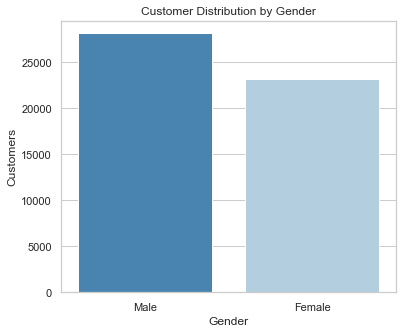

In [75]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=gender,
    x="Gender",
    y="Customers",
    palette="Blues_r"
)

plt.title("Customer Distribution by Gender")

plt.show()

## Insight

The customer base is relatively balanced between male and female shoppers, with a slight predominance of male customers. This suggests that the business appeals to both demographics without a significant gender imbalance.

# Final Business Conclusions

## Key Findings

- Sales showed a consistent upward trend throughout the year, with noticeable peaks during May, July, and November.
- Fashion generated both the highest total profit and the highest profit margin among all product categories.
- Sales and profit exhibited a very strong positive correlation (0.92), indicating that higher revenue is closely associated with higher profitability.
- Credit cards were by far the dominant payment method.
- Most customers were registered members, highlighting the importance of customer retention.
- Web purchases significantly exceeded mobile purchases.
- The customer base was relatively balanced between male and female shoppers.
- Medium-priority orders represented the majority of all transactions.

## Business Recommendations

- Continue investing in the Fashion category due to its superior profitability.
- Improve the mobile shopping experience to increase mobile sales.
- Maintain and optimize credit card payment processing.
- Strengthen loyalty programs to retain existing members.
- Monitor seasonal peaks to optimize inventory and staffing during high-demand months.

# Project Summary
This project demonstrates an end-to-end exploratory data analysis workflow using Python. Starting from raw transactional data, the analysis applies data cleaning, aggregation, visualization, and business interpretation to uncover actionable insights that support strategic decision-making.